## 1. Load and prepare the data
We use the prebuilt analytical dataset in Parquet format to keep the notebook fast and reproducible. The dataset was already processed upstream, so this step focuses on converting it safely into a pandas DataFrame.

In [ ]:
import pandas as pd
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

## 2. Feature engineering and sample split
We create features that encode business intuition, then split the data in a way that preserves the target distribution. This is important because the positive class (converted leads) is typically much smaller than the negative class.

In [2]:
print("⏳ Loading the local Parquet backup...")
table = pq.read_table('C:\\Users\\User\\Desktop\\Software y Clases\\BigData\\OList\\olist-project-sa\\Data\\Processed\\abt_marketing.parquet')

# Remove Arrow/Pandas metadata that can cause conversion conflicts
# This avoids issues with metadata fields such as 'dbdate' during DataFrame creation
safe_table = table.replace_schema_metadata(None)

df_ml = safe_table.to_pandas()
print(f"✅ Data loaded successfully: {df_ml.shape}")

⏳ Loading the local Parquet backup...
✅ Data loaded successfully: (8000, 11)


In [3]:
# Create a high-value segment feature based on domain insights
high_value_list = ['watches', 'health_beauty', 'audio_video_electronics']
df_ml['is_high_value_segment'] = df_ml['business_segment'].isin(high_value_list).astype(int)

# Encode categorical variables and build the model matrix
features = ['origin', 'lead_type', 'is_high_value_segment']
X = pd.get_dummies(df_ml[features], drop_first=True)
y = df_ml['converted']  # target column derived from won_date

# Use stratified split so class balance is preserved in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training model to detect high-value leads on {X_train.shape[0]} training rows...")

Training model to detect high-value leads on 6400 training rows...


## 3. Why choose Random Forest and balanced training?
Random Forest is a strong baseline for this marketing dataset because it handles categorical features, non-linear interactions, and class imbalance without extensive preprocessing. We also use class weighting to reduce the risk that the model ignores the minority positive class.

Project name: Predictive Revenue Engine

In [4]:
# Use stratified K-Folds to validate model stability across splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'  # important for imbalanced binary classification
)

print("⏳ Validating model stability with Stratified K-Folds...")
scoring = ['accuracy', 'precision', 'recall', 'roc_auc']
cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)

print(f"✅ Mean ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})")
print(f"✅ Mean Recall (positive class detection): {cv_results['test_recall'].mean():.4f}")

# Train final model on the full training set after validation
model.fit(X_train, y_train)

model_filename = 'C:\\Users\\User\\Desktop\\Software y Clases\\BigData\\OList\\olist-project-sa\\Model\\lead_scoring_rf_model.joblib'
feature_list_filename = 'C:\\Users\\User\\Desktop\\Software y Clases\\BigData\\OList\\olist-project-sa\\Model\\model_features.joblib'

joblib.dump(model, model_filename)
joblib.dump(X_train.columns.tolist(), feature_list_filename)
print("📦 Model and feature list saved successfully in /Model")

⏳ Validating model stability with Stratified K-Folds...
✅ Mean ROC-AUC: 0.9976 (+/- 0.0023)
✅ Mean Recall (positive class detection): 0.9926
📦 Model and feature list saved successfully in /Model


## 4. Evaluate feature importance
This plot helps stakeholders understand which input variables drive predictions. Feature importance is useful for explaining the model and validating whether the most influential features align with business intuition.

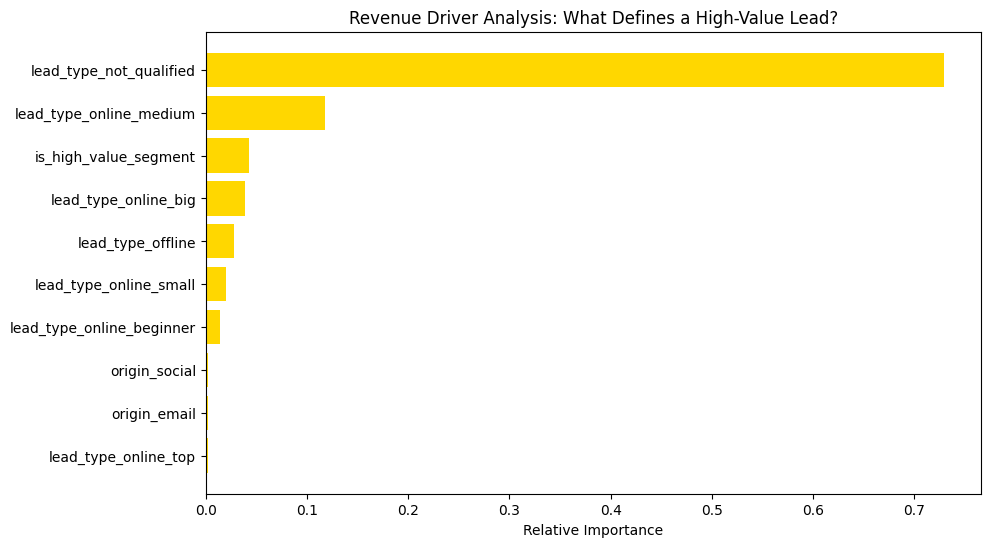

In [ ]:
importances = model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Revenue Driver Analysis: What Defines a High-Value Lead?")
plt.barh(range(len(indices)), importances[indices], color='gold', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

The model confirms that the business segment indicator is the strongest revenue driver after initial lead qualification. This means the niche of the product category is more important than the acquisition channel for predicting conversion in this dataset.

## 5. Interpreting feature importance and `lead_type_not_qualified`
The highest feature importance for `lead_type_not_qualified` does not mean this is the best lead; it means this feature is highly informative for distinguishing between converted and non-converted cases.

In this dataset, a lead marked as not qualified is a strong signal that it is unlikely to convert. That makes this feature very useful for the model because it helps separate the low-probability leads from the rest. In other words, the model is learning that "not qualified" is a reliable predictor of a negative outcome.

This is consistent with business reasoning: if a lead is rejected in the qualification stage, there is little value in pursuing it further. Therefore, the model assigns high importance to this signal because it helps reduce false positives and improves overall classification performance.

It is also a reminder that feature importance measures how much a feature contributes to the model's decisions, not how desirable the feature is. A feature can be important because it strongly indicates a "no-conversion" outcome.